In [1]:
import importlib
import stochastic_interpolants
importlib.reload(stochastic_interpolants)
from stochastic_interpolants import *

from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/njung3/miniconda3/envs/flow311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Create MLP Model with sin/cos embedding. Consult https://www.kaggle.com/code/lorentzyeung/positional-embeddings-clearly-explained for more information on this type of time embedding.

In [2]:
# image size
IMG_SIZE = 64
# input size
IN_S = IMG_SIZE ** 2
# hidden size
H_S = 1024
# amount of layers
L = 8
# output size
OUT_S = IN_S
# time dimensions
T_D = 128

model = MLP(input_size = IN_S, hidden_size = H_S, amount_layers = L, output_size = OUT_S, time_dimension = T_D)

Define Target Distribution

In [3]:
dataset_target = load_dataset("natejuw/swiss-roll-64x64_3")

Define Base Distribution

In [10]:
dataset_base = dataset_target.copy()
dataset_base["train"] = dataset_to_gaussian(dataset_base)

Prime the datasets for MLP

In [11]:
dataset_base["train"] = flatten_dataset(dataset_base)
dataset_target["train"]  = flatten_dataset(dataset_target)

dataset_base["train"].set_format("torch", columns=["pixel_values"])
dataset_target["train"].set_format("torch", columns=["pixel_values"])

Map: 100%|██████████| 10000/10000 [00:21<00:00, 466.98 examples/s]


Define Interpolant

In [29]:
interpolant = Interpolant('linear')

Now we want to train the model.

In [37]:
model = model.to(device)

train_type = 'velocity'
gradient_steps = 5000
batch_size = 200
log_every = 200
base_learning_rate = 1e-2
weight_decay = 1e-7
out_name = "noise_to_swiss_roll.pt"

interpolant.train_model(model = model, dataset_base = dataset_base, dataset_target = dataset_target, 
train_type = train_type, n_iterations = gradient_steps,
batch_size = batch_size, log_every = log_every, base_lr = 1e-3, weight_decay = 1e-7,
out_name = out_name)

step 200/5000 | obj 0.000030 | mse 0.130773 | grad_norm 0.0005797 | pred_mean 0.0006137 | I_mean 0.005172 | pred_std 0.0063
step 400/5000 | obj -0.000000 | mse 0.131270 | grad_norm 0.0006791 | pred_mean -0.0003668 | I_mean -0.003201 | pred_std 0.0070
step 600/5000 | obj 0.000015 | mse 0.131146 | grad_norm 0.000658 | pred_mean 0.0001945 | I_mean -5.333e-05 | pred_std 0.0062
step 800/5000 | obj 0.000035 | mse 0.132496 | grad_norm 0.0008915 | pred_mean 0.0009259 | I_mean 0.003151 | pred_std 0.0092
step 1000/5000 | obj 0.000005 | mse 0.128029 | grad_norm 0.000775 | pred_mean 0.002058 | I_mean 0.001059 | pred_std 0.0108
step 1200/5000 | obj 0.000069 | mse 0.132063 | grad_norm 0.001267 | pred_mean -0.001129 | I_mean 0.005995 | pred_std 0.0080
step 1400/5000 | obj 0.000055 | mse 0.136003 | grad_norm 0.00111 | pred_mean 0.0004345 | I_mean -0.0005077 | pred_std 0.0077
step 1600/5000 | obj 0.000021 | mse 0.131064 | grad_norm 0.0006419 | pred_mean 0.0009025 | I_mean -0.000342 | pred_std 0.0046
st

Now we view the flow

/home/njung3/code/flow_matching/stochastic_interpolants.py:279: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


starting from dataset item 4475


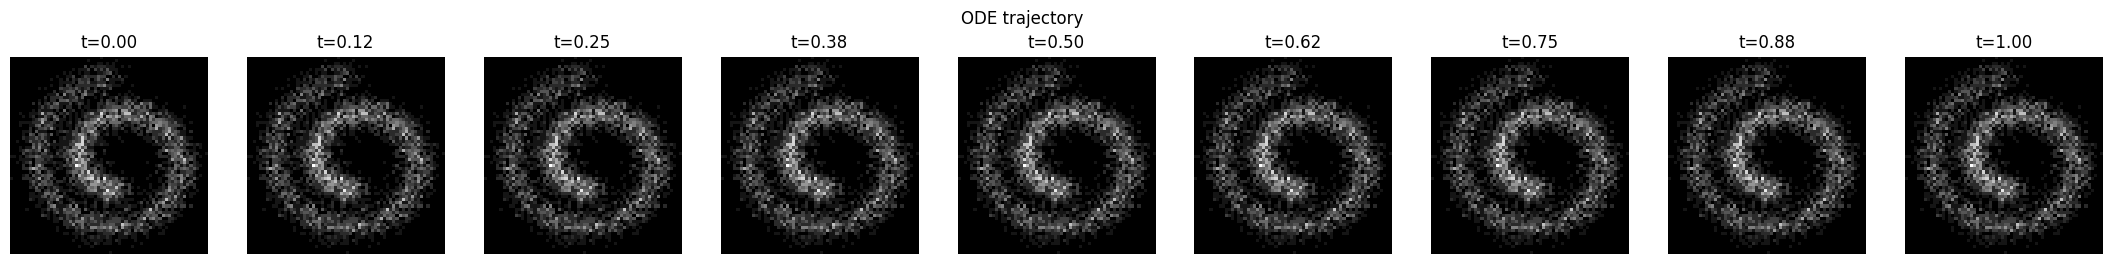

In [39]:
run_flow(dataset_base, model, n_steps = 1000, save_frames = 9, use_random=True)